# EEG publication analysis workspace

This notebook is the human-facing companion to the frozen EEG preprocessing pipeline. It is designed for inspection, figure review, exploratory play, and manuscript development without mutating Silver or Gold data.

## Questions

1. Do sustained EEG features differ between any-ad and no-ad conversations, inline and labelled-block formats, or early and late timing?
2. Do ad-locked post-onset changes differ from timing-matched no-ad replies?
3. Are conclusions stable across the 1,000, 1,050, and 1,500 µV artifact policies?
4. Which participant-level patterns and uncertainty ranges should drive interpretation?

## Analysis hierarchy

- **Primary:** Fz theta and posterior alpha with prespecified participant-level contrasts.
- **Secondary:** global theta/alpha/beta, FAA, and factorial interactions.
- **Exploratory:** engagement ratios, delta/gamma, and relative powers.

The participant is the replication unit. A non-significant result is not evidence of absence.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

# Resolve the repository whether the notebook starts from its own folder or repo root.
START = Path.cwd().resolve()
REPO_ROOT = next(
    path for path in (START, *START.parents)
    if (path / "analysis/eeg/preprocessing").exists()
)
ANALYSIS_ROOT = REPO_ROOT / "analysis/eeg/analysis"
OUTPUT_ROOT = ANALYSIS_ROOT / "outputs"
if str(ANALYSIS_ROOT) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_ROOT))

from run_publication_analysis import run

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
plt.rcParams["figure.dpi"] = 120
print(f"Repository: {REPO_ROOT}")
print(f"Analysis workspace: {ANALYSIS_ROOT}")

Repository: /home/wtroi/MasterThesis-RAG-RecSys
Analysis workspace: /home/wtroi/MasterThesis-RAG-RecSys/analysis/eeg/analysis


## 1. Reproduce the complete analysis

This calls the production runner. It reads immutable Gold and statistics inputs, regenerates all tables and figures, hashes the inputs, and fails if any of twenty quality gates fails.

In [2]:
manifest = run(
    ANALYSIS_ROOT / "analysis_config.json",
    OUTPUT_ROOT,
)
print(manifest["status"])
print(f"Quality gates: {manifest['quality_gates']['passed']}/{manifest['quality_gates']['total']}")

Generated publication analysis with 20/20 quality gates passing under /home/wtroi/MasterThesis-RAG-RecSys/analysis/eeg/analysis/outputs
initial_publication_scaffold_ready_human_gates_pending
Quality gates: 20/20


In [3]:
quality = json.loads((OUTPUT_ROOT / "reports/quality_gates.json").read_text())
quality_table = pd.DataFrame(
    [{"quality_gate": key, "passed": value} for key, value in quality["checks"].items()]
)
display(quality_table)
assert quality["status"] == "pass"

,quality_gate,passed
0,01_soundness_machine_checks_pass,True
1,02_condition_validation_passes,True
2,03_ad_validation_passes,True
3,04_engagement_validation_passes,True
4,05_expected_18_participants,True
5,06_complete_condition_cells,True
6,07_complete_ad_reference_cells,True
7,08_no_duplicate_condition_keys,True
8,09_no_duplicate_ad_keys,True
9,10_primary_policy_is_frozen_v3,True


## 2. Inspect the analysis-ready datasets

There are two complementary participant-level datasets:

- `condition_features.csv`: one baseline or sustained-condition window per participant and condition.
- `ad_response_features.csv`: one pre/post response pair per participant and ad or matched no-ad reference.

The larger epoch table is available for artifact and retention diagnostics, but inferential tests use participant-level summaries.

In [4]:
GOLD = REPO_ROOT / "src/project/logs/xdf/gold/features"
STATS = REPO_ROOT / "analysis/eeg/statistics/outputs"

condition = pd.read_csv(GOLD / "condition_features.csv")
ad_response = pd.read_csv(GOLD / "ad_response_features.csv")
condition_epochs = pd.read_csv(GOLD / "condition_epoch_features.csv")
condition_tests = pd.read_csv(STATS / "eeg_condition_contrasts.csv")
ad_tests = pd.read_csv(STATS / "eeg_ad_response_contrasts.csv")
condition_scores = pd.read_csv(STATS / "eeg_condition_contrast_scores.csv")
ad_scores = pd.read_csv(STATS / "eeg_ad_response_contrast_scores.csv")

summary = pd.DataFrame([
    {"dataset": "condition summaries", "rows": len(condition), "participants": condition.subject_id.nunique(), "grain": "participant × baseline/condition window"},
    {"dataset": "condition epochs", "rows": len(condition_epochs), "participants": condition_epochs.subject_id.nunique(), "grain": "participant × window × 4-second epoch"},
    {"dataset": "ad responses", "rows": len(ad_response), "participants": ad_response.subject_id.nunique(), "grain": "participant × ad/no-ad response pair"},
])
display(summary)
display(condition.head(3))

,dataset,rows,participants,grain
0,condition summaries,108,18,participant × baseline/condition window
1,condition epochs,9468,18,participant × window × 4-second epoch
2,ad responses,108,18,participant × ad/no-ad response pair


,subject_id,experiment_id,window_id,window_type,condition,ad_mode,trial_index,baseline_eye_state,epoch_duration_s,complete_epoch_count,retained_epoch_count,retained_epoch_fraction,retained_duration_s,minimum_retained_fraction,minimum_retained_epochs,primary_analysis_eligible,exclusion_reason,artifact_policy_status,ica_applied,max_peak_to_peak_uv_p50,max_peak_to_peak_uv_p95,max_abs_amplitude_uv_p95,epochs_with_near_flat_channel,delta_power_db_uv2_median,delta_power_db_uv2_iqr,theta_power_db_uv2_median,theta_power_db_uv2_iqr,alpha_power_db_uv2_median,alpha_power_db_uv2_iqr,beta_power_db_uv2_median,beta_power_db_uv2_iqr,gamma_power_db_uv2_median,gamma_power_db_uv2_iqr,delta_relative_power_median,delta_relative_power_iqr,theta_relative_power_median,theta_relative_power_iqr,alpha_relative_power_median,alpha_relative_power_iqr,beta_relative_power_median,beta_relative_power_iqr,gamma_relative_power_median,gamma_relative_power_iqr,fz_theta_power_db_uv2_median,fz_theta_power_db_uv2_iqr,posterior_alpha_power_db_uv2_median,posterior_alpha_power_db_uv2_iqr,faa_log_f4_minus_f3_median,faa_log_f4_minus_f3_iqr,engagement_beta_over_alpha_theta_median,engagement_beta_over_alpha_theta_iqr,engagement_pope_frontocentral_beta_over_alpha_theta_median,engagement_pope_frontocentral_beta_over_alpha_theta_iqr,engagement_kislov_central_beta16_24_over_alpha8_12_median,engagement_kislov_central_beta16_24_over_alpha8_12_iqr,source_xdf,source_xdf_sha256,delta_power_db_uv2_baseline_delta,theta_power_db_uv2_baseline_delta,alpha_power_db_uv2_baseline_delta,beta_power_db_uv2_baseline_delta,gamma_power_db_uv2_baseline_delta,delta_relative_power_baseline_delta,theta_relative_power_baseline_delta,alpha_relative_power_baseline_delta,beta_relative_power_baseline_delta,gamma_relative_power_baseline_delta,fz_theta_power_db_uv2_baseline_delta,posterior_alpha_power_db_uv2_baseline_delta,faa_log_f4_minus_f3_baseline_delta,engagement_beta_over_alpha_theta_baseline_delta,engagement_pope_frontocentral_beta_over_alpha_theta_baseline_delta,engagement_kislov_central_beta16_24_over_alpha8_12_baseline_delta
0,lab_subject_10,exp_20260728T091433Z_242026ac,lab_subject_10__baseline_00,baseline,baseline,none,NaN,uncontrolled_mostly_open,4.0,7,7,1.000000,28.0,0.8,5,yes,NaN,frozen_v3,no,252.878928,392.417444,256.669748,0,20.122425,6.402999,10.098715,4.566408,10.686629,2.161842,6.197234,0.569566,-1.827679,1.345295,0.789219,0.150303,0.094917,0.051890,0.063628,0.042105,0.027796,0.038193,0.005253,0.005953,11.909913,4.750144,10.181977,1.837229,-0.166432,0.819247,0.196610,0.119888,0.223492,0.073467,0.178447,0.054873,src/project/logs/xdf/bronze/lab_subject_10/sub...,735d4b5380a835680817fdfd39293323bd68b740db79f4...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,lab_subject_10,exp_20260728T091433Z_242026ac,lab_subject_10__condition_00,condition,inline_late,inline_persuasive,0.0,not_applicable,4.0,239,238,0.995816,952.0,0.8,5,yes,NaN,frozen_v3,no,338.038488,445.728840,326.169344,0,22.659102,4.617288,15.083945,3.820176,9.919848,2.173275,6.150524,1.317499,-1.975563,1.555772,0.773799,0.118709,0.153388,0.052614,0.046936,0.046702,0.019821,0.022894,0.003225,0.005044,14.535033,3.267343,9.482311,2.157484,0.126156,0.662325,0.102754,0.081601,0.156605,0.106765,0.219228,0.106340,src/project/logs/xdf/bronze/lab_subject_10/sub...,735d4b5380a835680817fdfd39293323bd68b740db79f4...,2.536677,4.985230,-0.766781,-0.046710,-0.147884,-0.015420,0.058471,-0.016692,-0.007976,-0.002028,2.625119,-0.699667,0.292588,-0.093857,-0.066887,0.040781
2,lab_subject_10,exp_20260728T091433Z_242026ac,lab_subject_10__condition_01,condition,block_early,explicit_ad_block,0.0,not_applicable,4.0,164,162,0.987805,648.0,0.8,5,yes,NaN,frozen_v3,no,325.997430,458.196434,334.427013,0,21.200120,5.214851,13.986911,3.834456,10.065055,1.791492,6.256435,1.268062,-1.755121,4.127977,0.762482,0.112938,0.149075,0.041085,0.057572,0.053987,0.024284,0.029505

In [5]:
# Compact data dictionary for the columns most useful during analysis.
data_dictionary = pd.DataFrame([
    ("subject_id", "Participant identifier; the inferential replication unit"),
    ("condition", "No-ad, inline/block, and early/late condition cell"),
    ("retained_epoch_fraction", "Fraction of complete 4-second epochs retained"),
    ("primary_analysis_eligible", "Frozen eligibility decision"),
    ("fz_theta_power_db_uv2_median", "Median Fz theta power within a sustained window"),
    ("posterior_alpha_power_db_uv2_median", "Median posterior alpha across O/P region"),
    ("*_post_minus_pre", "Ad-locked post-onset minus pre-onset response"),
    ("faa_log_f4_minus_f3", "Log alpha F4 minus log alpha F3"),
    ("engagement_*", "Exploratory ratio features; not direct psychological measures"),
], columns=["field", "meaning"])
display(data_dictionary)

,field,meaning
0,subject_id,Participant identifier; the inferential replic...
1,condition,"No-ad, inline/block, and early/late condition ..."
2,retained_epoch_fraction,Fraction of complete 4-second epochs retained
3,primary_analysis_eligible,Frozen eligibility decision
4,fz_theta_power_db_uv2_median,Median Fz theta power within a sustained window
5,posterior_alpha_power_db_uv2_median,Median posterior alpha across O/P region
6,*_post_minus_pre,Ad-locked post-onset minus pre-onset response
7,faa_log_f4_minus_f3,Log alpha F4 minus log alpha F3
8,engagement_*,Exploratory ratio features; not direct psychol...


## 3. Cohort and retention

The flow figure deliberately separates participants, sustained windows, four-second epochs, and ad/no-ad response pairs because these counts are not interchangeable.

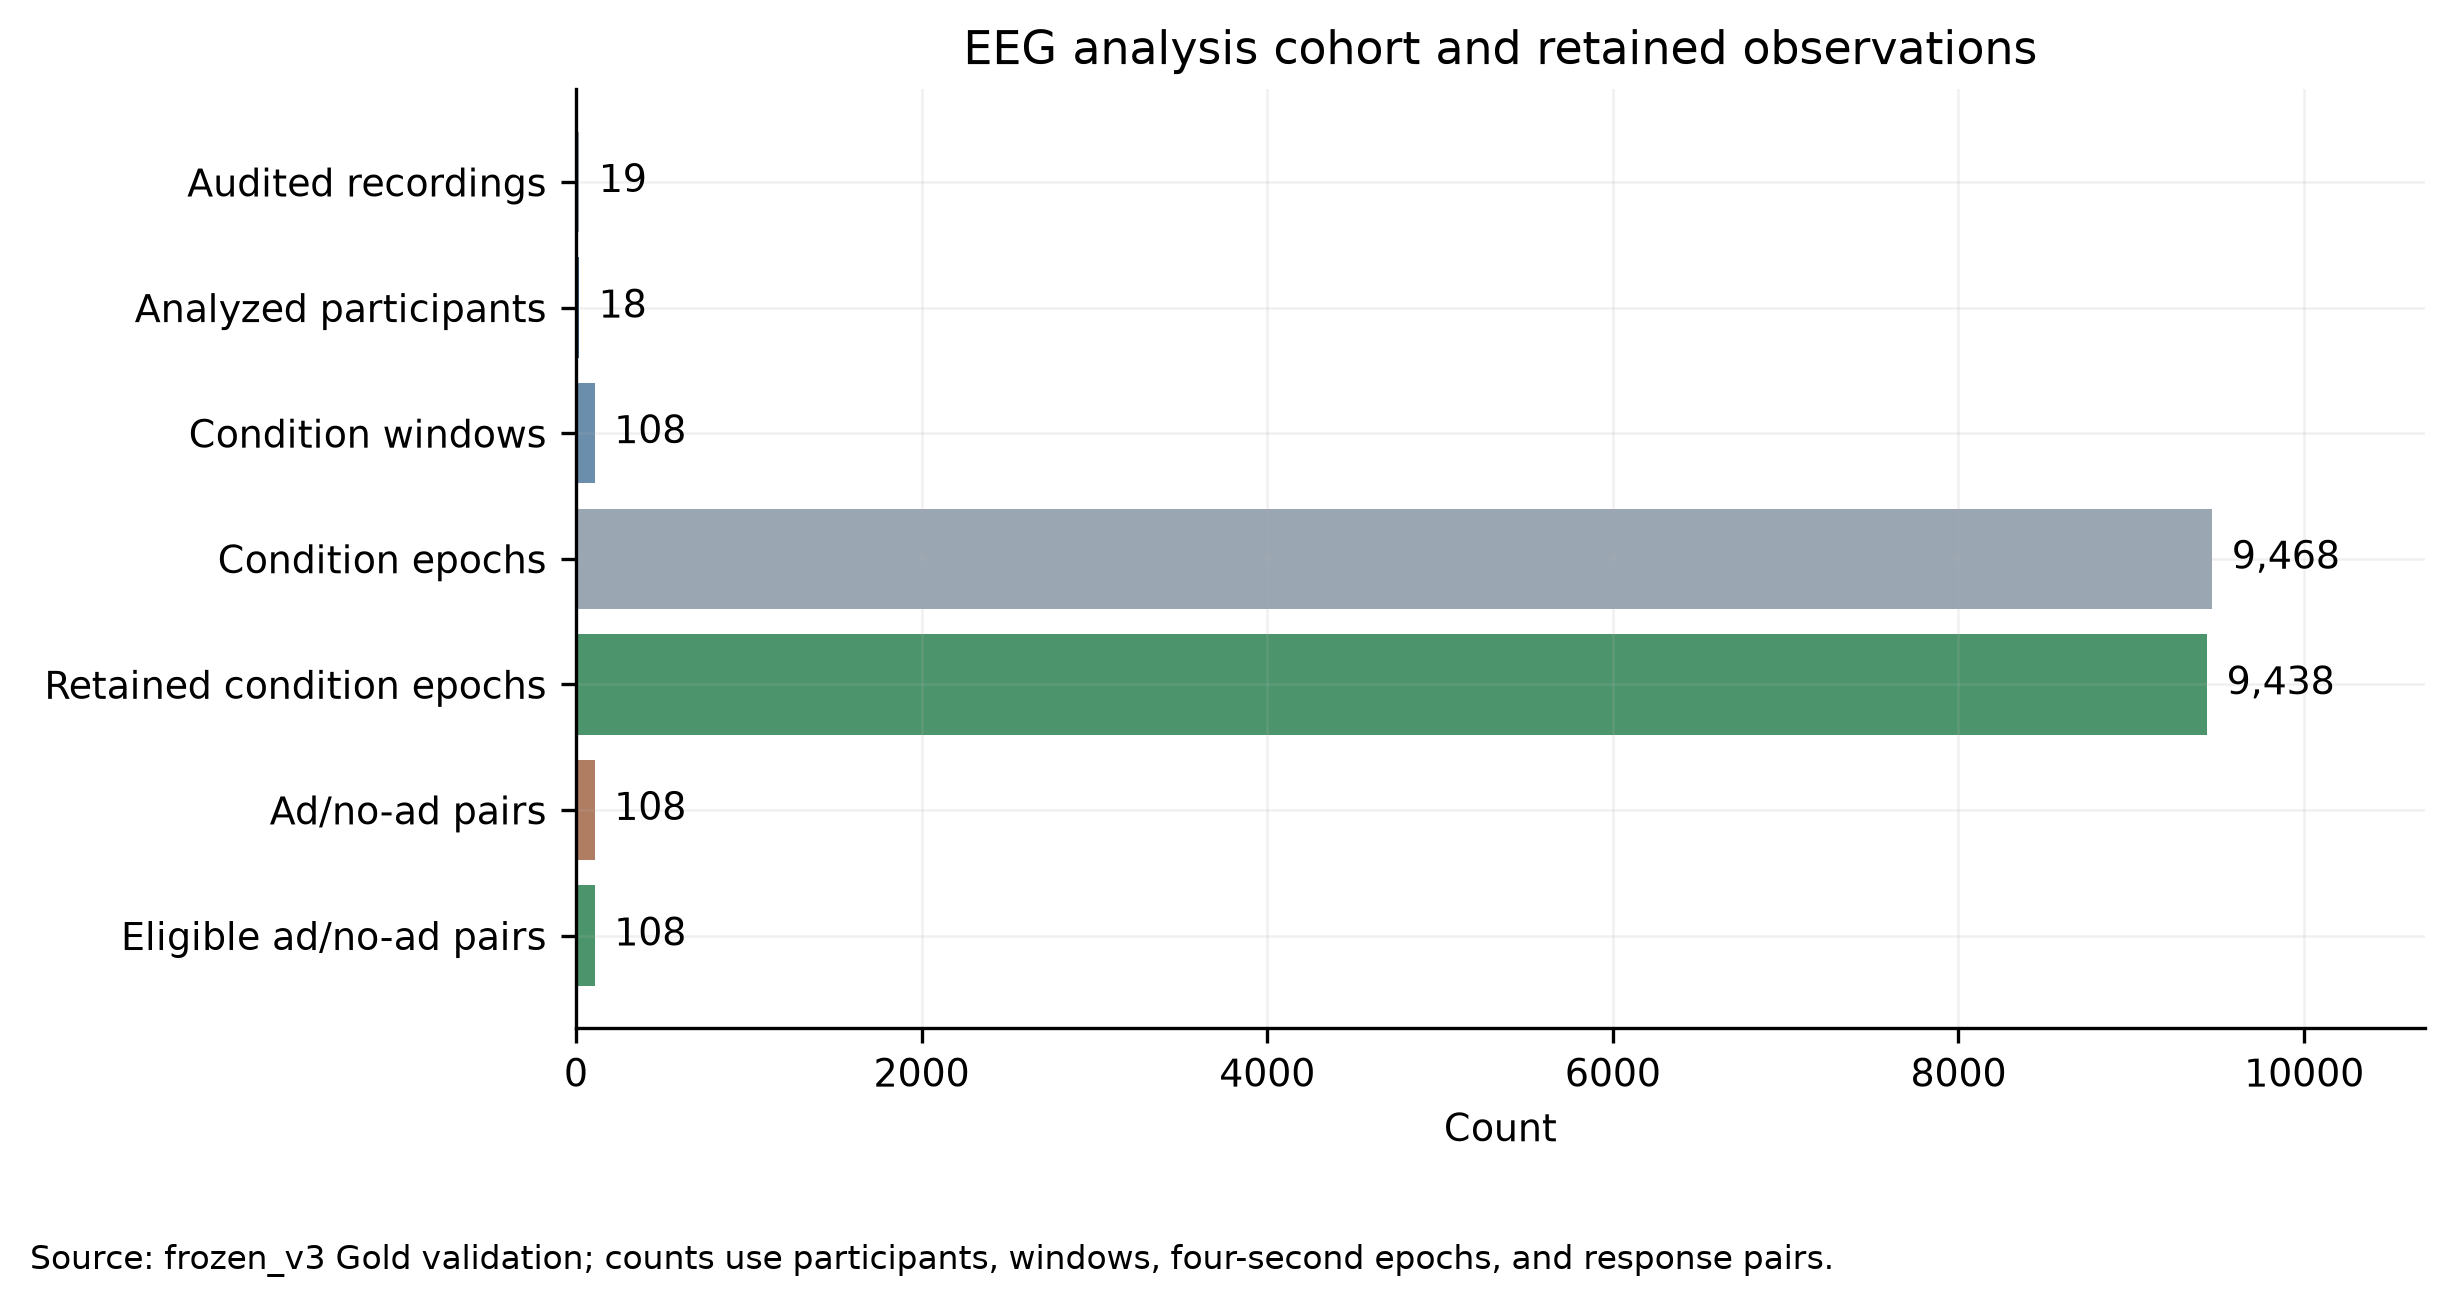

,metric,value
0,audited_recordings,19
1,wrong_protocol_exclusions,1
2,participants,18
3,condition_windows,108
4,condition_epochs,9468
5,retained_condition_epochs,9438
6,retained_condition_fraction,0.9968314321926489
7,ad_response_pairs,108
8,eligible_ad_response_pairs,108
9,maximum_ad_timing_uncertainty_s,0.433055


In [6]:
display(Image(filename=str(OUTPUT_ROOT / "figures/figure_01_data_flow.png")))
qc = pd.read_csv(OUTPUT_ROOT / "tables/cohort_qc_summary.csv")
display(qc)

## 4. Primary sustained-condition analysis

Three contrasts are tested separately for Fz theta and posterior alpha. Holm correction is applied across the three contrasts within each feature. A second, more conservative column corrects all six primary tests together. Bootstrap intervals and leave-one-participant-out stability accompany the parametric estimates. The uncontrolled baseline is not part of these confirmatory tests.

,contrast_label,feature_label,n_participants,mean_difference,ci_lower,ci_upper,bootstrap_mean_ci_lower,bootstrap_mean_ci_upper,cohen_dz,p_t_raw,p_t_holm,p_t_holm_global_primary_family,p_wilcoxon_holm,leave_one_out_sign_stability,holm_significant
0,Any ad − no ads,Fz theta power (dB µV²),18,0.0192,-0.2486,0.2870,-0.2204,0.2608,0.0356,0.8817,0.8817,1.0000,0.9323,0.7778,False
1,Inline − labelled block,Fz theta power (dB µV²),18,-0.1324,-0.3822,0.1174,-0.3667,0.0881,-0.2635,0.2791,0.8372,1.0000,0.7936,1.0000,False
2,Early − late,Fz theta power (dB µV²),18,-0.0643,-0.2218,0.0933,-0.2062,0.0786,-0.2028,0.4014,0.8372,1.0000,0.7936,1.0000,False
3,Any ad − no ads,Posterior alpha power (dB µV²),18,0.0675,-0.1150,0.2499,-0.0982,0.2334,0.1839,0.4459,0.8918,1.0000,0.9366,1.0000,False
4,Inline − labelled block,Posterior alpha power (dB µV²),18,0.0064,-0.1569,0.1697,-0.1527,0.1421,0.0196,0.9347,0.9347,1.0000,0.9366,0.5556,False
5,Early − late,Posterior alpha power (dB µV²),18,-0.0888,-0.2006,0.0231,-0.1908,0.0099,-0.3947,0.1124,0.3371,0.6741,0.4246,1.0000,False


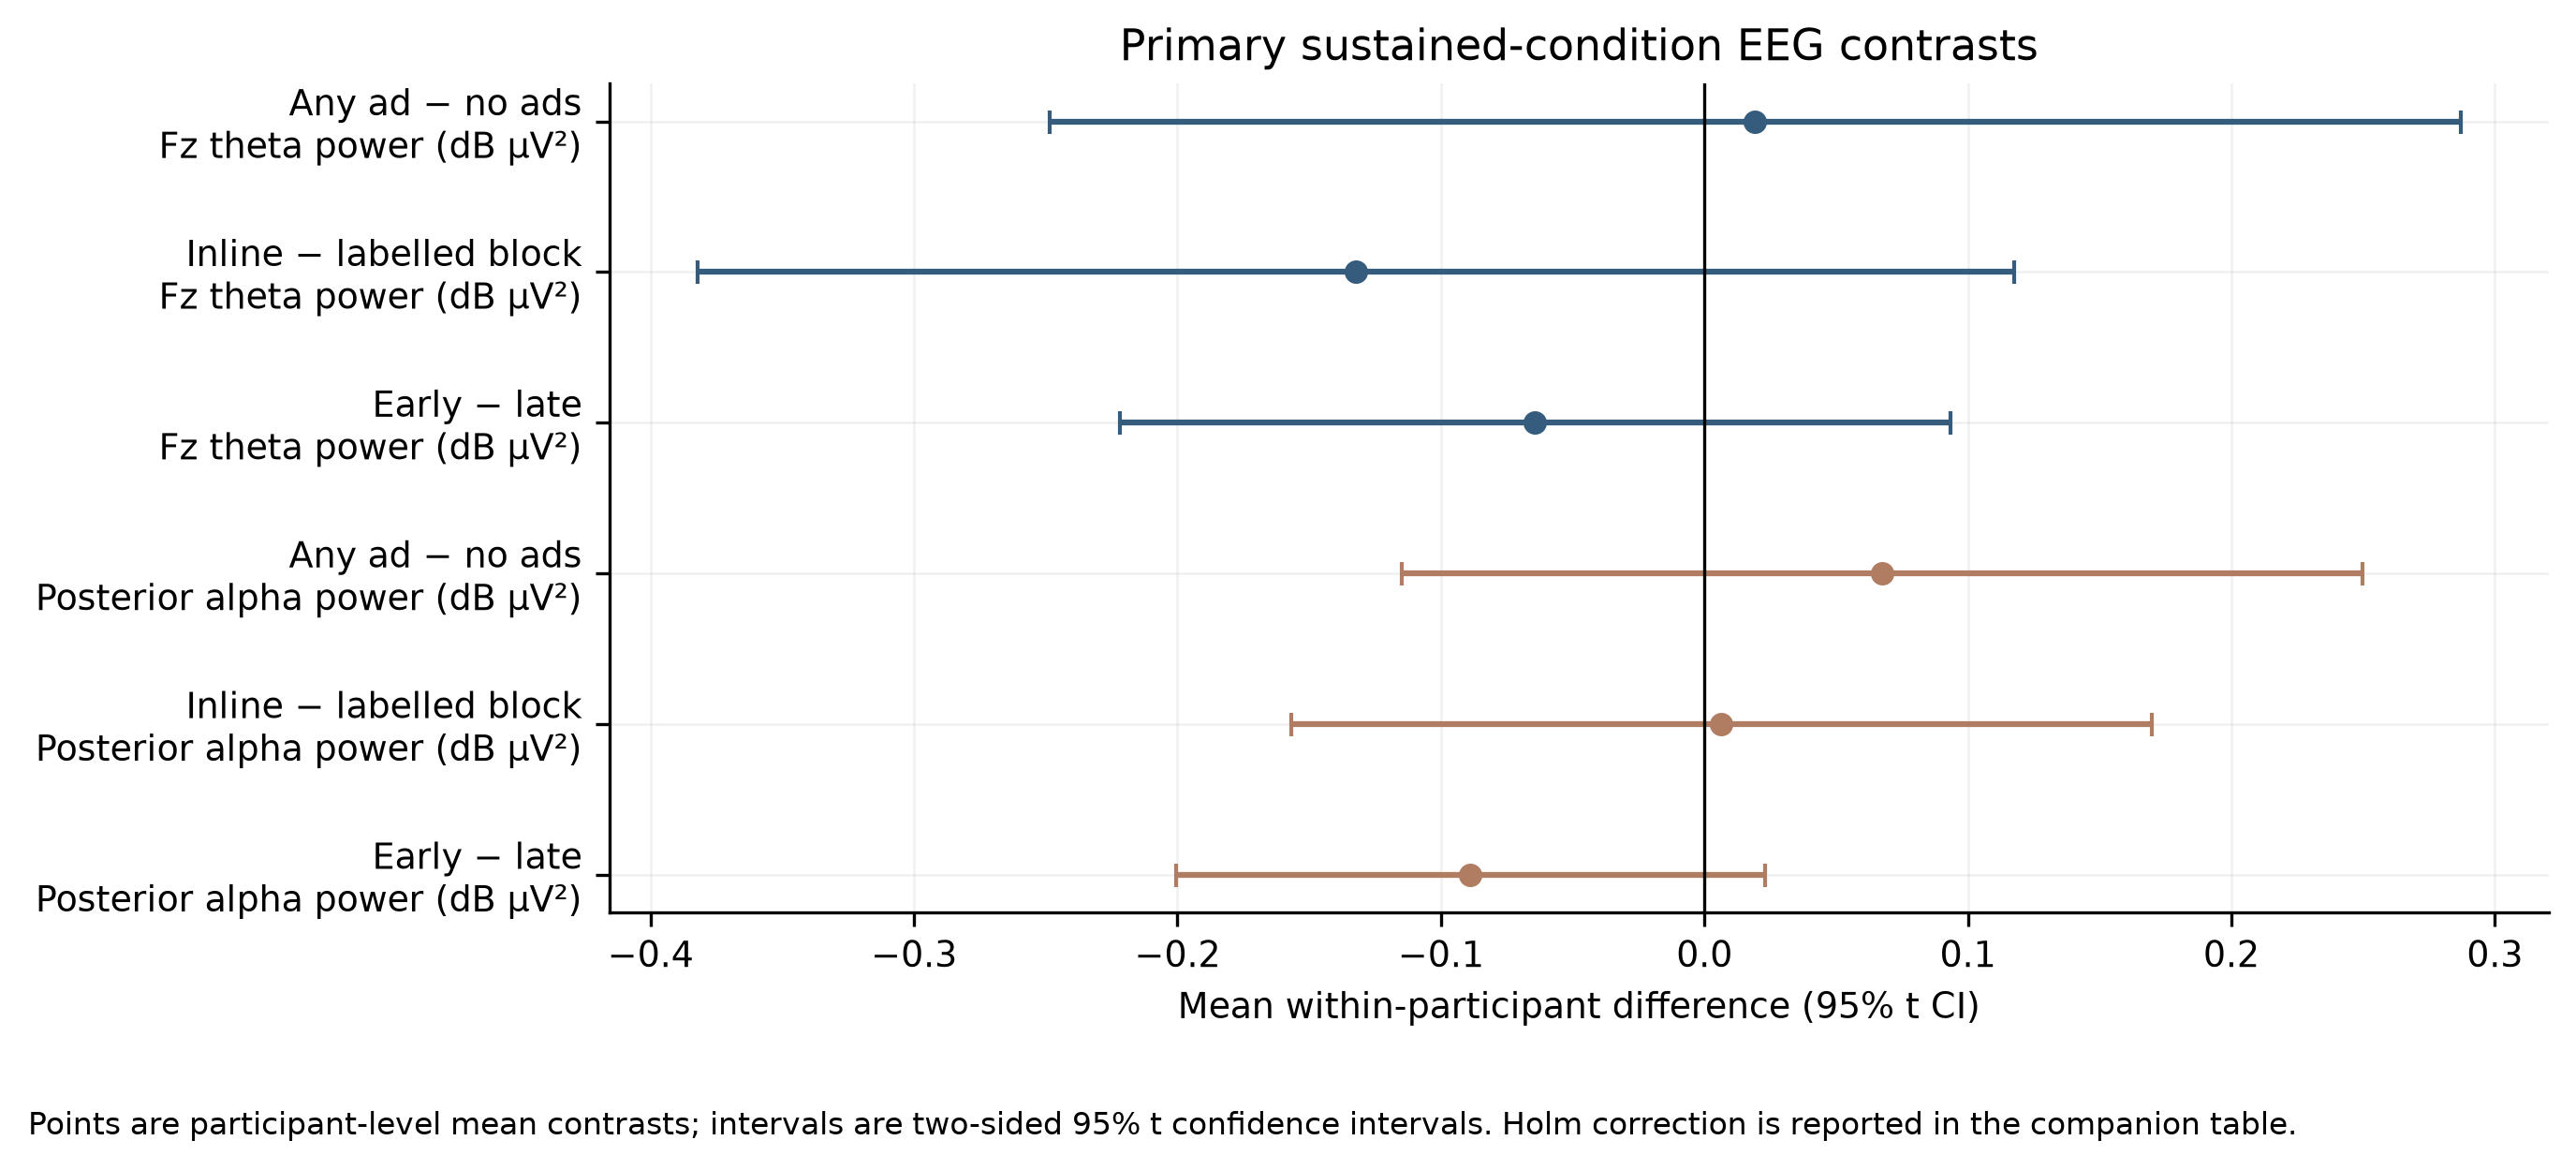

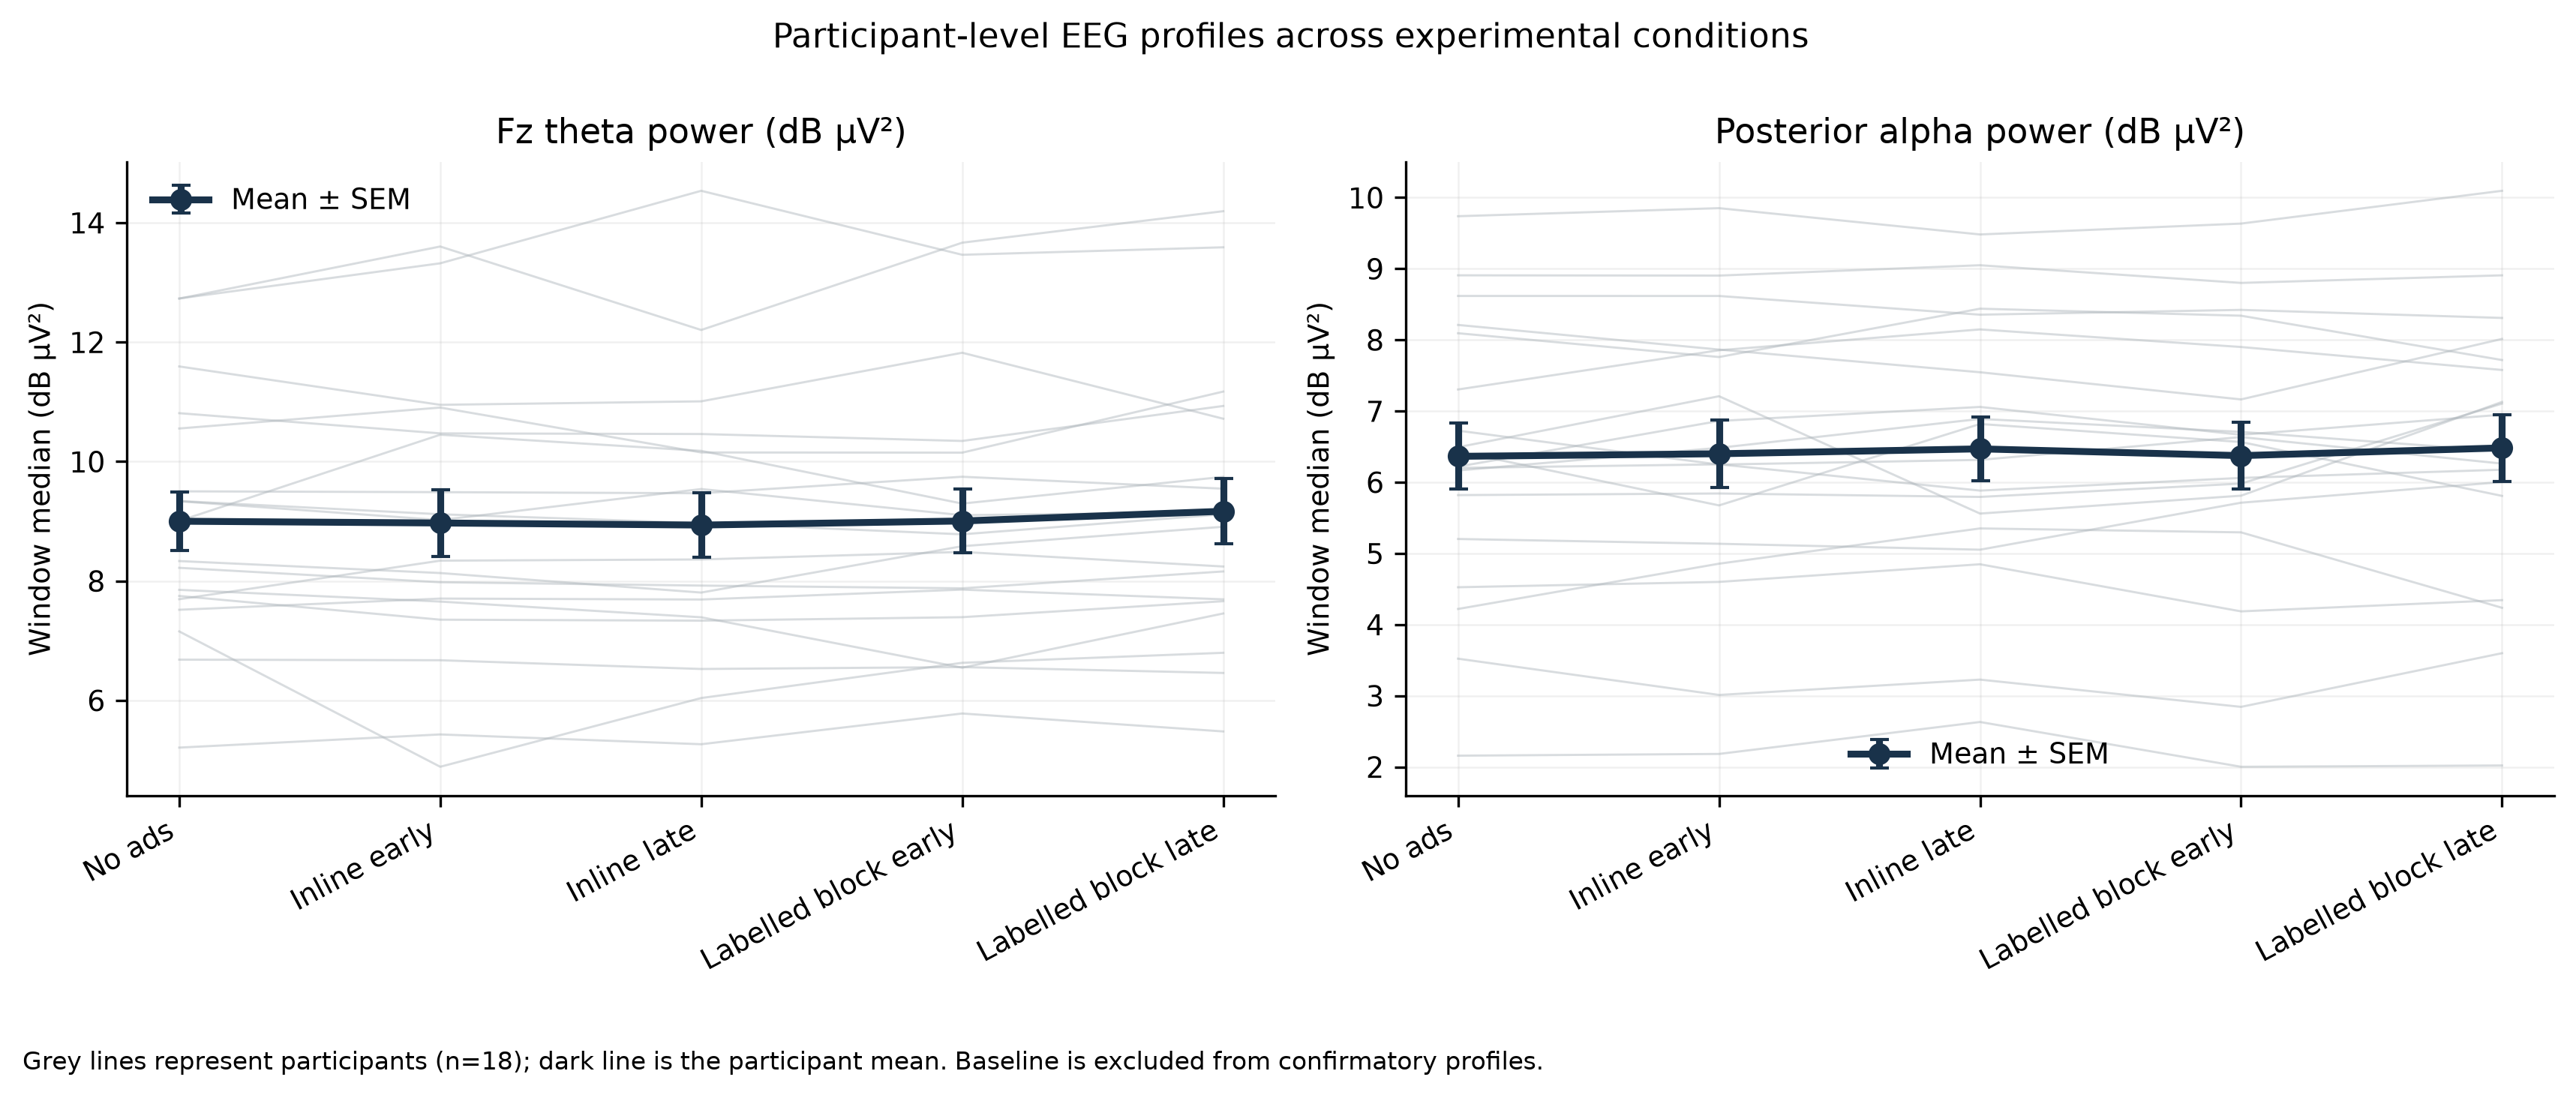

In [7]:
primary_condition = pd.read_csv(OUTPUT_ROOT / "tables/primary_condition_results.csv")
columns = [
    "contrast_label", "feature_label", "n_participants", "mean_difference",
    "ci_lower", "ci_upper", "bootstrap_mean_ci_lower", "bootstrap_mean_ci_upper",
    "cohen_dz", "p_t_raw", "p_t_holm", "p_t_holm_global_primary_family",
    "p_wilcoxon_holm", "leave_one_out_sign_stability", "holm_significant",
]
display(primary_condition[columns].round(4))
display(Image(filename=str(OUTPUT_ROOT / "figures/figure_02_condition_primary_forest.png")))
display(Image(filename=str(OUTPUT_ROOT / "figures/figure_04_condition_profiles.png")))

## 5. Primary ad-locked response analysis

Each ad cell is compared with a no-ad reply projected at the same early or late turn. The response is `post − pre` over adjacent four-second epochs. Holm correction is applied across four ad-versus-control contrasts within each feature; a global eight-test Holm column is included as a conservative sensitivity.

,contrast_label,feature_label,n_participants,mean_difference,ci_lower,ci_upper,bootstrap_mean_ci_lower,bootstrap_mean_ci_upper,cohen_dz,p_t_raw,p_t_holm,p_t_holm_global_primary_family,p_wilcoxon_holm,leave_one_out_sign_stability,holm_significant
0,Inline early − matched no-ad,Fz theta power (dB µV²),18,-0.2523,-2.1028,1.5981,-1.8846,1.4062,-0.0678,0.7771,1.0000,1.0000,0.8846,0.8889,False
1,Labelled block early − matched no-ad,Fz theta power (dB µV²),18,0.7242,-1.3061,2.7544,-1.1917,2.4717,0.1774,0.4620,1.0000,1.0000,0.6364,1.0000,False
2,Inline late − matched no-ad,Fz theta power (dB µV²),18,-1.9922,-3.9420,-0.0425,-3.7656,-0.2801,-0.5081,0.0457,0.1829,0.3658,0.2661,1.0000,False
3,Labelled block late − matched no-ad,Fz theta power (dB µV²),18,-0.7491,-2.5468,1.0485,-2.4120,0.9108,-0.2072,0.3915,1.0000,1.0000,0.8846,1.0000,False
4,Inline early − matched no-ad,Posterior alpha power (dB µV²),18,0.1046,-1.8434,2.0526,-1.7635,1.7153,0.0267,0.9111,1.0000,1.0000,1.0000,0.6111,False
5,Labelled block early − matched no-ad,Posterior alpha power (dB µV²),18,0.3600,-2.0247,2.7446,-1.9151,2.4658,0.0751,0.7540,1.0000,1.0000,1.0000,1.0000,False
6,Inline late − matched no-ad,Posterior alpha power (dB µV²),18,-0.9941,-2.7112,0.7230,-2.6191,0.5431,-0.2879,0.2386,0.7158,1.0000,0.7386,1.0000,False
7,Labelled block late − matched no-ad,Posterior alpha power (dB µV²),18,-1.1035,-2.3977,0.1908,-2.3146,0.0432,-0.4240,0.0898,0.3593,0.6288,0.4748,1.0000,False


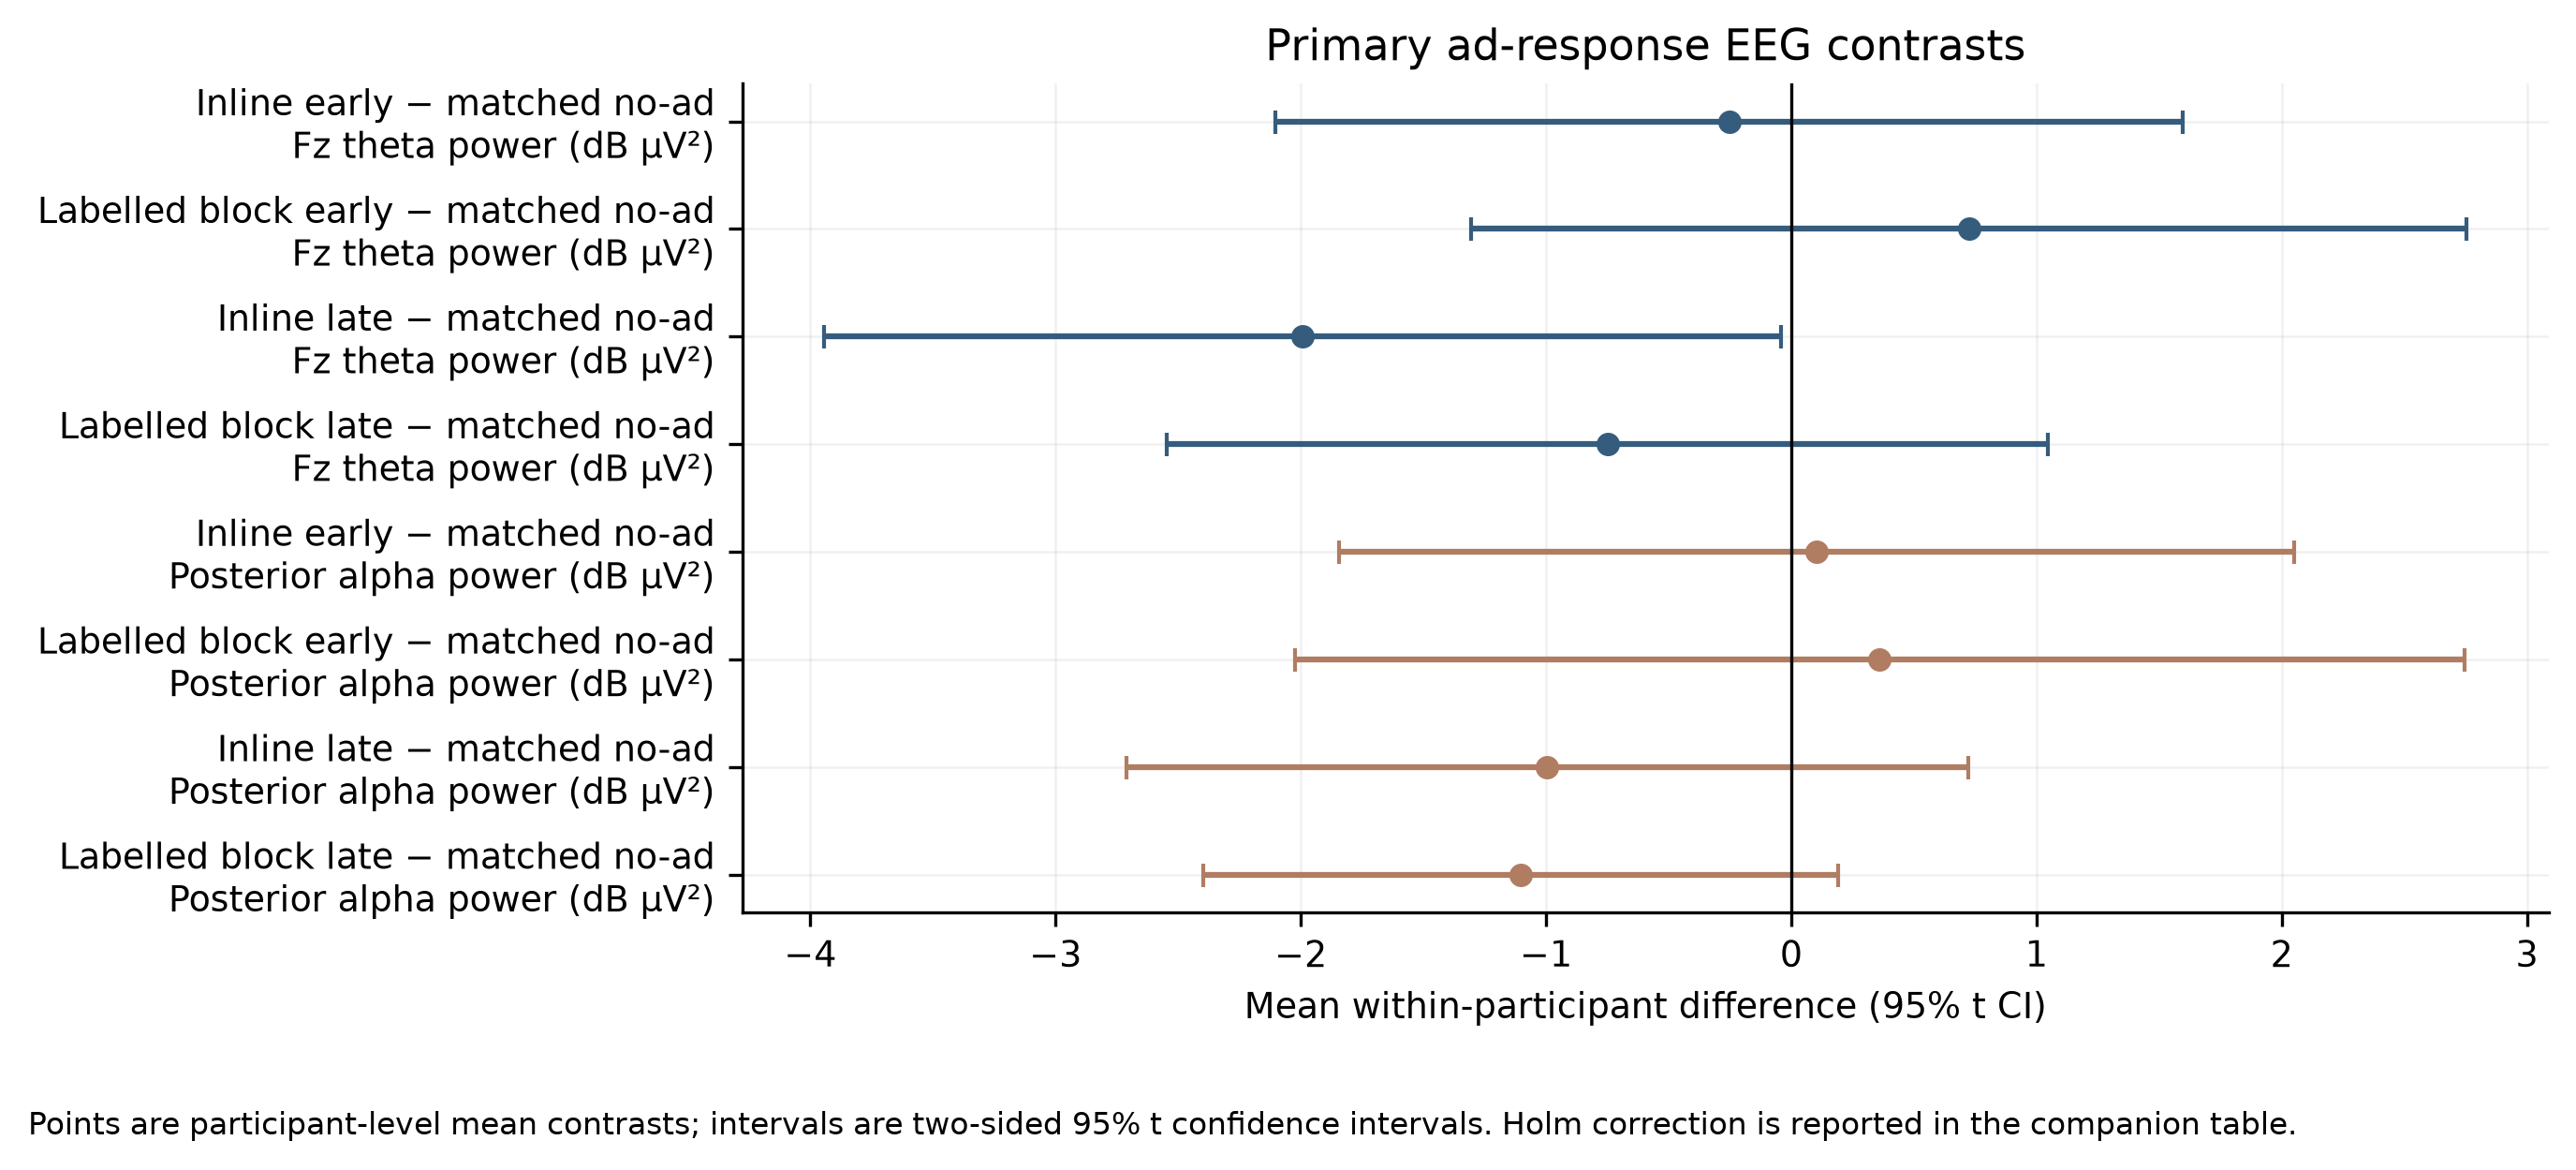

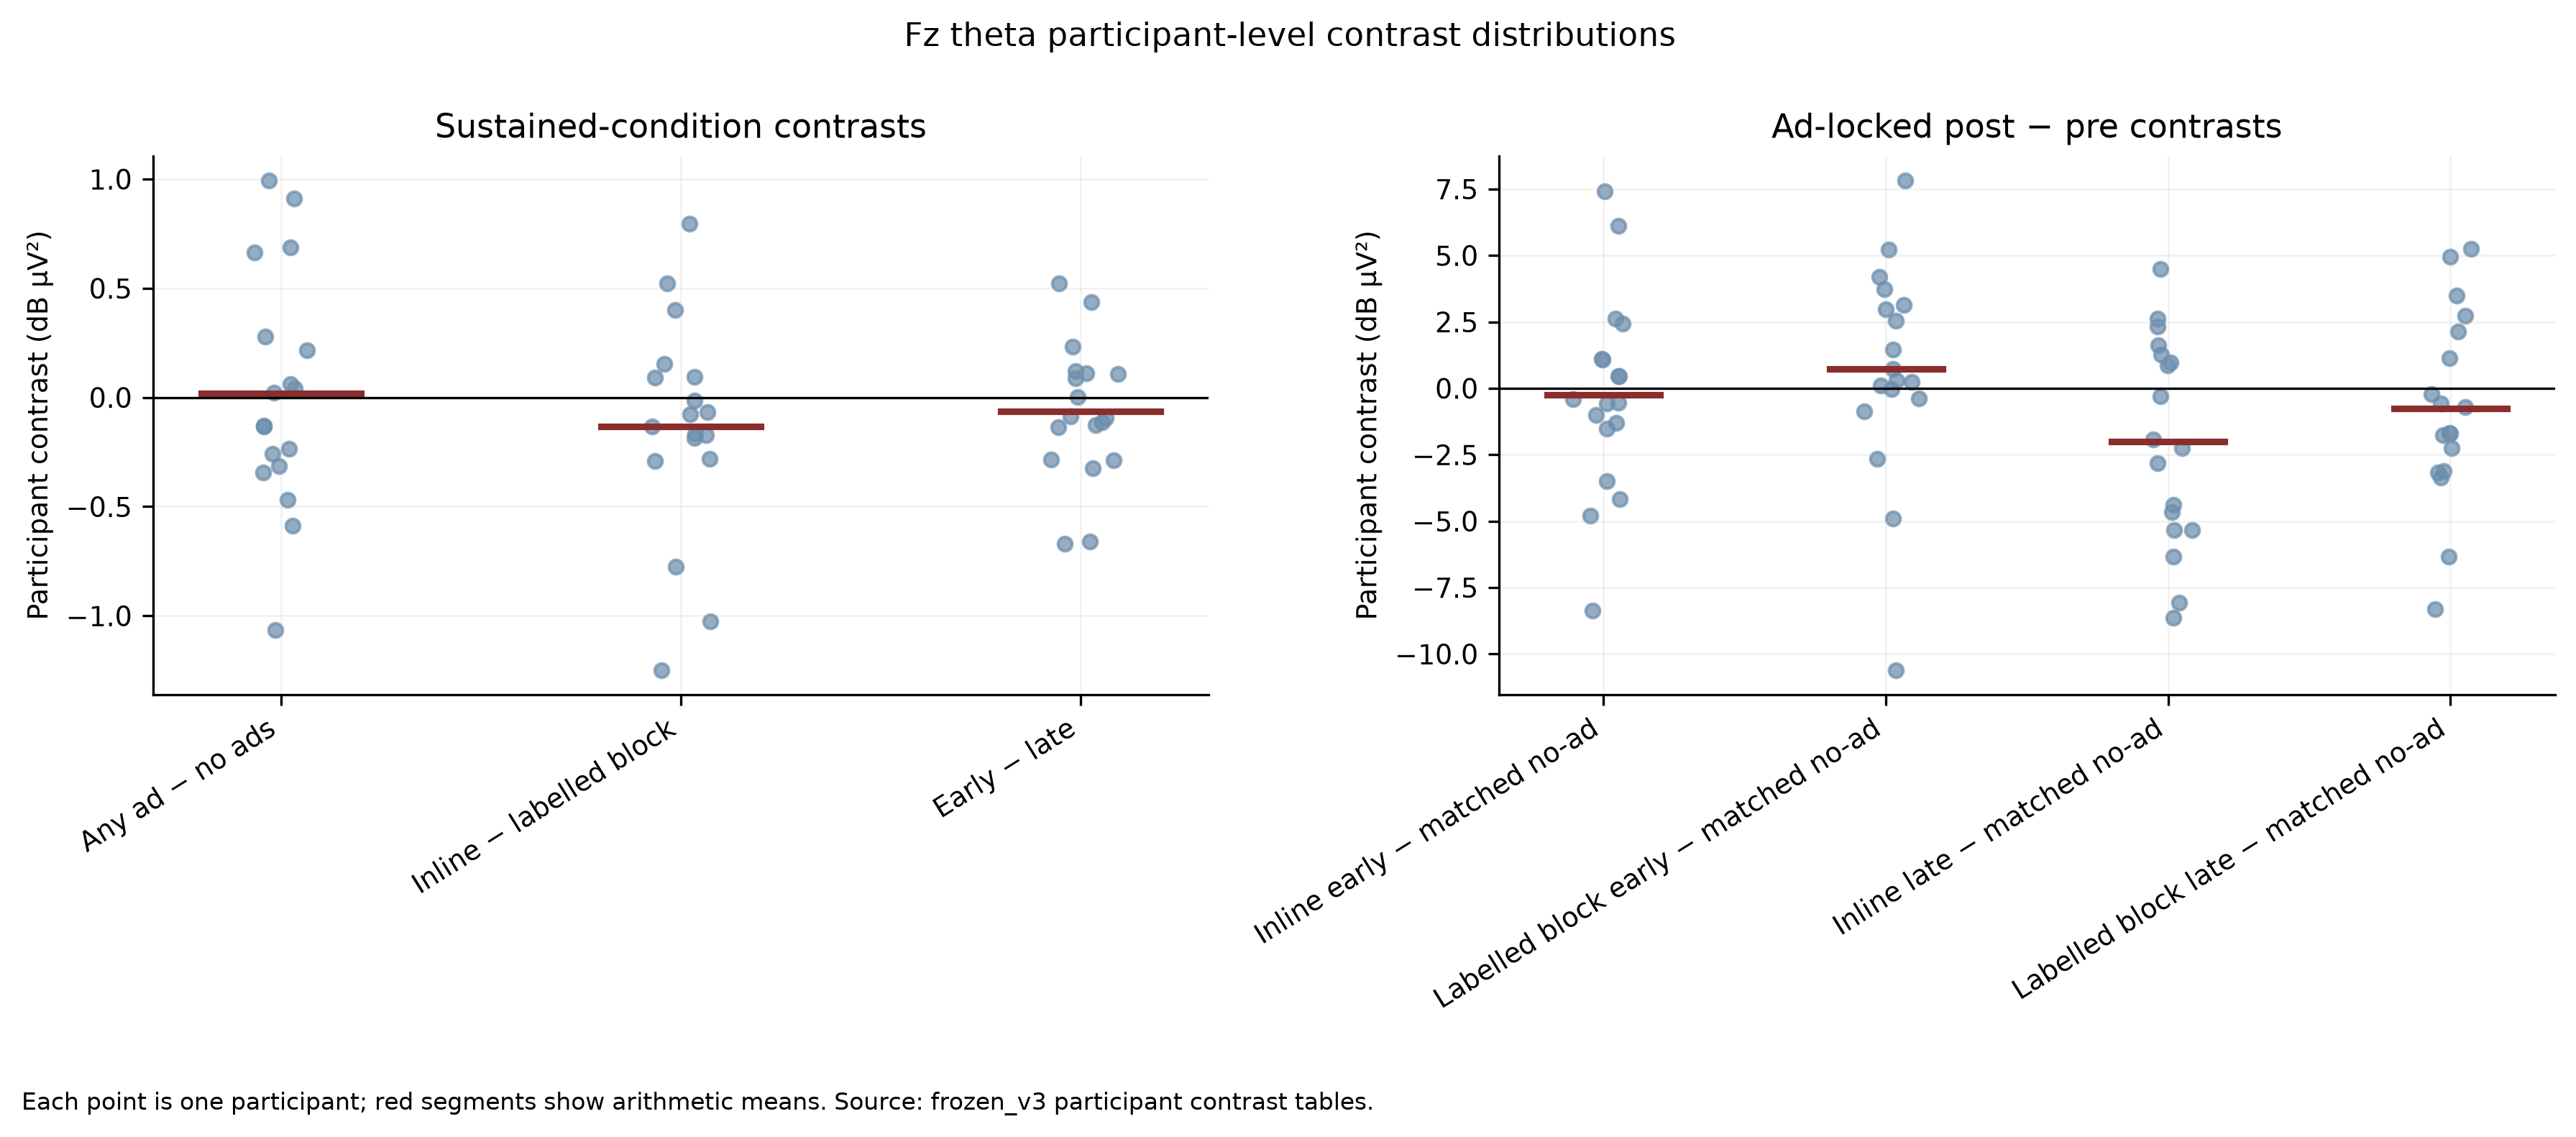

In [8]:
primary_ad = pd.read_csv(OUTPUT_ROOT / "tables/primary_ad_results.csv")
display(primary_ad[columns].round(4))
display(Image(filename=str(OUTPUT_ROOT / "figures/figure_03_ad_primary_forest.png")))
display(Image(filename=str(OUTPUT_ROOT / "figures/figure_05_participant_distributions.png")))

## 6. Assumption and influence diagnostics

With only 18 participants, diagnostics are descriptive rather than mechanical pass/fail filters. Compare the t-test with Wilcoxon results, inspect skew and outliers, and emphasize leave-one-participant-out sign stability. Do not delete a participant solely because a normality test is significant.

,analysis,contrast_id,feature,feature_label,n_participants,mean_difference,median_difference,skewness,shapiro_w,shapiro_p,rank_biserial,iqr_outlier_count,bootstrap_mean_ci_lower,bootstrap_mean_ci_upper,leave_one_out_sign_stability,maximum_leave_one_out_mean_shift
7,condition,inline_vs_block,posterior_alpha_power_db_uv2,Posterior alpha power (dB µV²),18,0.0064,0.0921,-1.2155,0.8785,0.0246,0.2047,2,-0.1527,0.1421,0.5556,0.0453
19,ad,inline_early_vs_no_ad_early,posterior_alpha_power_db_uv2,Posterior alpha power (dB µV²),18,0.1046,-0.0727,-1.3969,0.8842,0.0308,0.1579,1,-1.7635,1.7153,0.6111,0.6803
23,ad,inline_vs_block,posterior_alpha_power_db_uv2,Posterior alpha power (dB µV²),18,-0.0730,-0.0632,0.1159,0.9858,0.9902,-0.0994,0,-1.0177,0.8941,0.6667,0.2673
5,condition,format_x_timing,posterior_alpha_power_db_uv2,Posterior alpha power (dB µV²),18,0.0401,0.0230,0.6376,0.9585,0.5725,-0.0058,1,-0.4609,0.5635,0.7778,0.1721
0,condition,any_ad_vs_no_ads,fz_theta_power_db_uv2,Fz theta power (dB µV²),18,0.0192,-0.0523,0.2035,0.9643,0.6858,-0.0292,0,-0.2204,0.2608,0.7778,0.0639
17,ad,format_x_timing,posterior_alpha_power_db_uv2,Posterior alpha power (dB µV²),18,-0.3648,0.2020,0.3821,0.9599,0.6000,-0.0877,0,-2.6270,1.9965,0.8333,0.7228
16,ad,format_x_timing,fz_theta_power_db_uv2,Fz theta power (dB µV²),18,0.2666,0.1386,0.5272,0.9732,0.8557,0.0409,1,-2.0146,2.7255,0.8333,0.7507
18,ad,inline_early_vs_no_ad_early,fz_theta_power_db_uv2,Fz theta power (dB µV²),18,-0.2523,-0.4867,0.0377,0.9656,0.7115,-0.1111,3,-1.8846,1.4062,0.8889,0.4780
10,ad,block_early_vs_no_ad_early,fz_theta_power_db_uv2,Fz theta power (dB µV²),18,0.7242,0.5153,-1.0966,0.9238,0.1508,0.3450,1,-1.1917,2.4717,1.0000,0.6668
6,condition,inline_vs_block,fz_theta_power_db_uv2,Fz theta power (dB µV²),18,-0.1324,-0.1044,-0.5774,0.9363,0.2503,-0.3099,3,-0.3667,0.0881,1.0000,0.0657


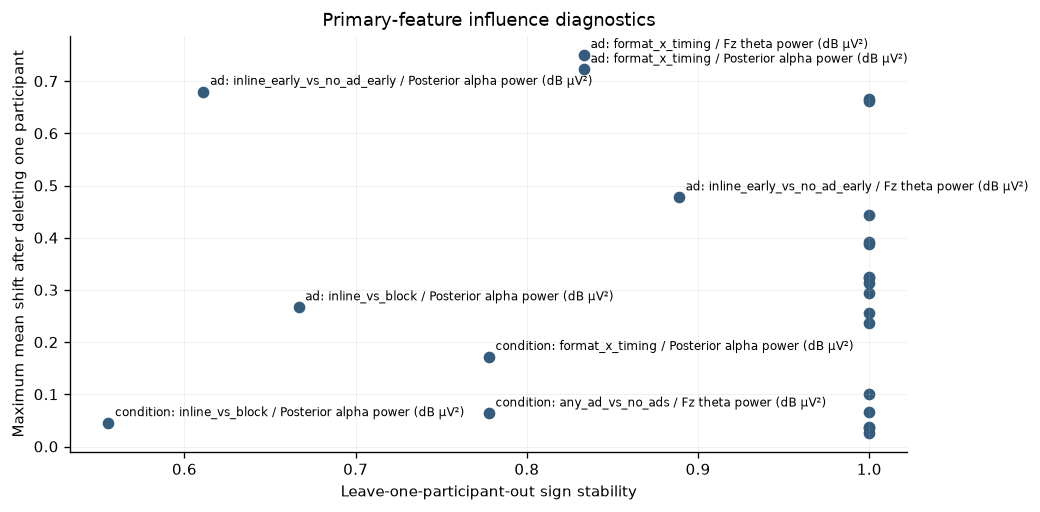

In [9]:
diagnostics = pd.read_csv(OUTPUT_ROOT / "tables/assumption_influence_diagnostics.csv")
display(
    diagnostics.sort_values(
        ["leave_one_out_sign_stability", "shapiro_p"]
    ).round(4)
)

fig, ax = plt.subplots(figsize=(9, 4.5))
plot_data = diagnostics.copy()
labels = plot_data["analysis"] + ": " + plot_data["contrast_id"] + " / " + plot_data["feature_label"]
ax.scatter(plot_data["leave_one_out_sign_stability"], plot_data["maximum_leave_one_out_mean_shift"], color="#355C7D")
for x, y, label in zip(plot_data["leave_one_out_sign_stability"], plot_data["maximum_leave_one_out_mean_shift"], labels):
    if x < 1.0:
        ax.annotate(label, (x, y), fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Leave-one-participant-out sign stability")
ax.set_ylabel("Maximum mean shift after deleting one participant")
ax.set_title("Primary-feature influence diagnostics")
plt.show()

## 7. Artifact-threshold sensitivity

The 1,050 µV primary cutoff was selected after observing Subject 14's 1,042.56 µV epoch. It is therefore post-review and participant-retention-driven. The 1,000 and 1,500 µV branches are mandatory, not optional.

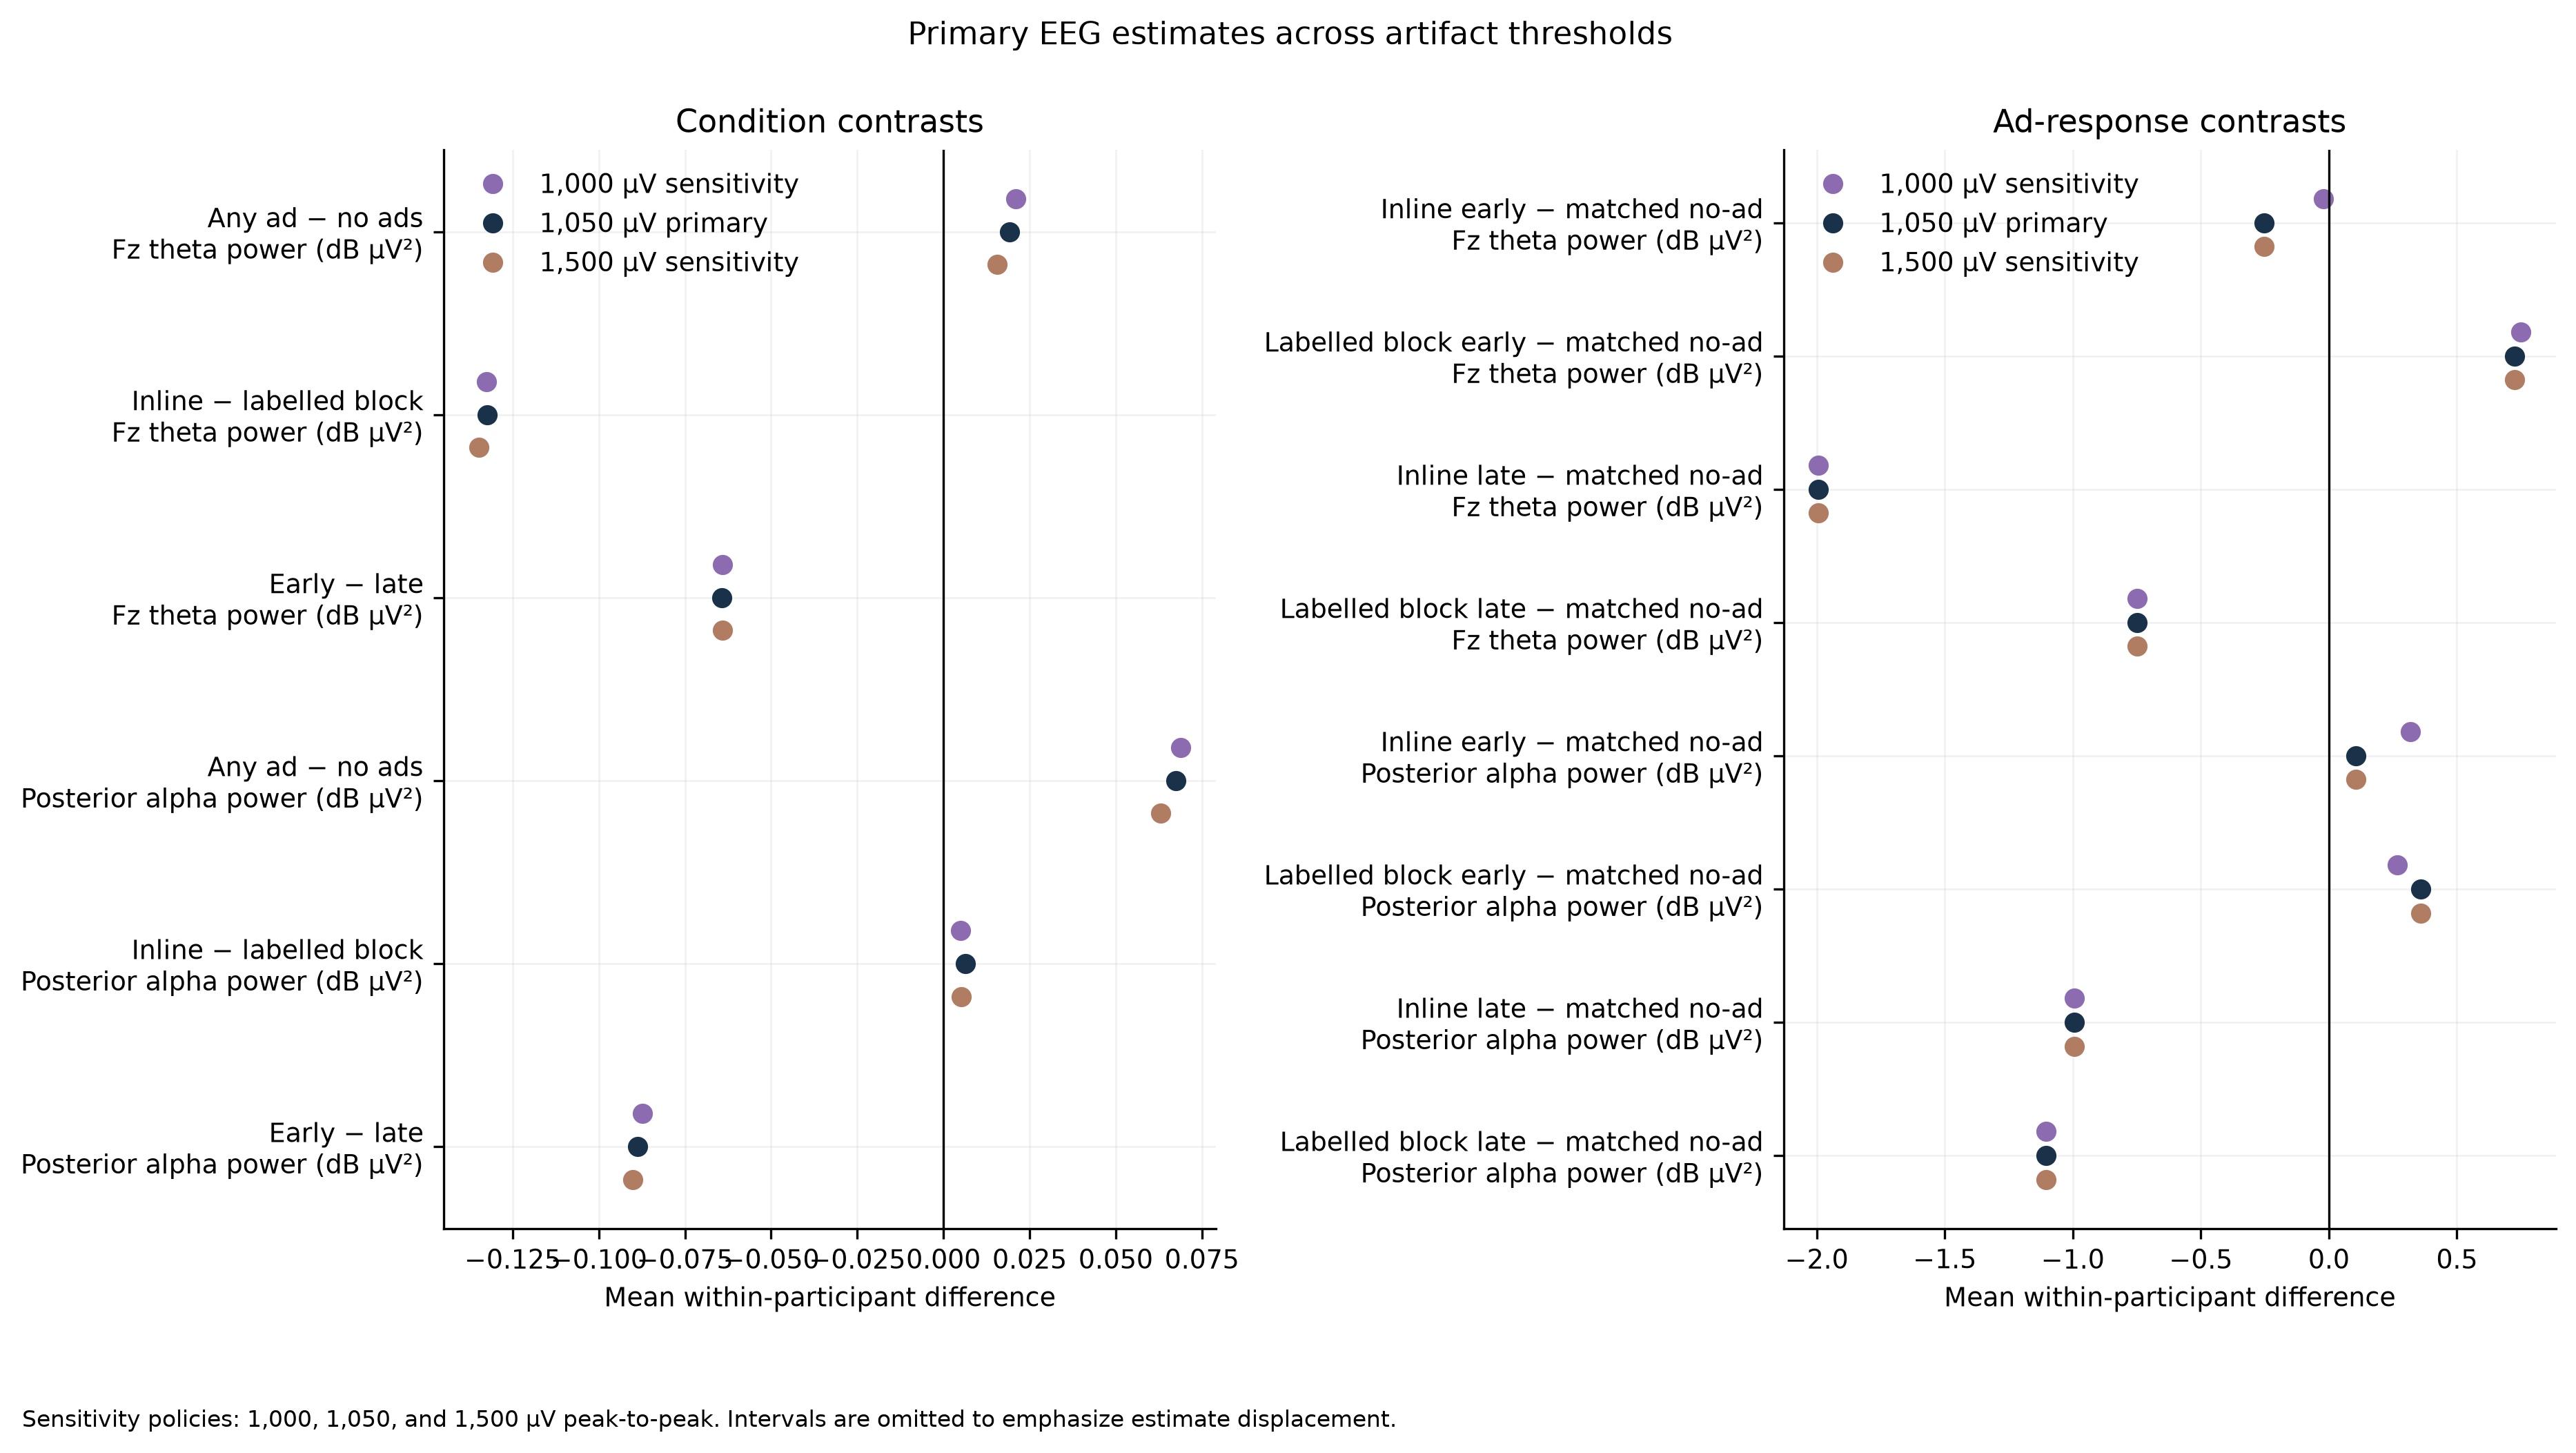

policy,analysis,contrast_id,feature,frozen_v1_1000_uv,frozen_v2_1500_uv,frozen_v3_1050_uv,1000_minus_1050,1500_minus_1050
0,ad,block_early_vs_no_ad_early,fz_theta_power_db_uv2,0.7497,0.7242,0.7242,0.0256,0.0000
1,ad,block_early_vs_no_ad_early,posterior_alpha_power_db_uv2,0.2680,0.3600,0.3600,-0.0919,0.0000
2,ad,block_late_vs_no_ad_late,fz_theta_power_db_uv2,-0.7491,-0.7491,-0.7491,0.0000,0.0000
3,ad,block_late_vs_no_ad_late,posterior_alpha_power_db_uv2,-1.1035,-1.1035,-1.1035,0.0000,0.0000
4,ad,inline_early_vs_no_ad_early,fz_theta_power_db_uv2,-0.0214,-0.2523,-0.2523,0.2309,0.0000
5,ad,inline_early_vs_no_ad_early,posterior_alpha_power_db_uv2,0.3181,0.1046,0.1046,0.2135,0.0000
6,ad,inline_late_vs_no_ad_late,fz_theta_power_db_uv2,-1.9922,-1.9922,-1.9922,0.0000,0.0000
7,ad,inline_late_vs_no_ad_late,posterior_alpha_power_db_uv2,-0.9941,-0.9941,-0.9941,0.0000,0.0000
8,condition,any_ad_vs_no_ads,fz_theta_power_db_uv2,0.0211,0.0157,0.0192,0.0019,-0.0035
9,condition,any_ad_vs_no_ads,posterior_alpha_power_db_uv2,0.0689,0.0631,0.0675,0.0015,-0.0044


In [10]:
sensitivity = pd.read_csv(OUTPUT_ROOT / "tables/threshold_sensitivity_results.csv")
display(Image(filename=str(OUTPUT_ROOT / "figures/figure_06_threshold_sensitivity.png")))

# Estimate displacement relative to the 1,050 µV primary policy.
index_columns = ["analysis", "contrast_id", "feature"]
wide = sensitivity.pivot_table(index=index_columns, columns="policy", values="mean_difference")
wide["1000_minus_1050"] = wide["frozen_v1_1000_uv"] - wide["frozen_v3_1050_uv"]
wide["1500_minus_1050"] = wide["frozen_v2_1500_uv"] - wide["frozen_v3_1050_uv"]
display(wide.reset_index().round(4))

## 8. Subject 14 and onset-provenance sensitivities

Subject 14 is shown explicitly because the primary 1,050 µV policy was selected just above one known epoch. The onset table separately identifies observed and reconstructed ad timings; reconstructed inline onsets support four-second spectra but not ERP-latency claims.

In [11]:
subject14 = pd.read_csv(OUTPUT_ROOT / "tables/subject14_influence.csv")
onset_provenance = pd.read_csv(OUTPUT_ROOT / "tables/ad_onset_provenance.csv")

display(Markdown("### Leave-Subject-14-out primary-feature contrasts"))
display(subject14.round(4))
display(Markdown("### Ad/no-ad onset provenance"))
display(onset_provenance.round(6))

### Leave-Subject-14-out primary-feature contrasts

,analysis,contrast_id,feature,feature_label,full_n,without_subject14_n,full_mean_difference,without_subject14_mean_difference,mean_shift,full_cohen_dz,without_subject14_cohen_dz,direction_changed
0,condition,any_ad_vs_no_ads,fz_theta_power_db_uv2,Fz theta power (dB µV²),18,17,0.0192,0.0549,0.0358,0.0356,0.1031,False
1,condition,any_ad_vs_no_ads,posterior_alpha_power_db_uv2,Posterior alpha power (dB µV²),18,17,0.0675,0.0294,-0.0381,0.1839,0.0865,False
2,condition,early_vs_late,fz_theta_power_db_uv2,Fz theta power (dB µV²),18,17,-0.0643,-0.0491,0.0152,-0.2028,-0.1535,False
3,condition,early_vs_late,posterior_alpha_power_db_uv2,Posterior alpha power (dB µV²),18,17,-0.0888,-0.1106,-0.0218,-0.3947,-0.5234,False
4,condition,format_x_timing,fz_theta_power_db_uv2,Fz theta power (dB µV²),18,17,0.1976,0.1404,-0.0572,0.2250,0.1613,False
5,condition,format_x_timing,posterior_alpha_power_db_uv2,Posterior alpha power (dB µV²),18,17,0.0401,0.1339,0.0938,0.0353,0.1224,False
6,condition,inline_vs_block,fz_theta_power_db_uv2,Fz theta power (dB µV²),18,17,-0.1324,-0.1709,-0.0385,-0.2635,-0.3489,False
7,condition,inline_vs_block,posterior_alpha_power_db_uv2,Posterior alpha power (dB µV²),18,17,0.0064,-0.0130,-0.0195,0.0196,-0.0398,True
8,ad,any_ad_vs_matched_no_ad,fz_theta_power_db_uv2,Fz theta power (dB µV²),18,17,-0.5674,-0.4402,0.1272,-0.2036,-0.1562,False
9,ad,any_ad_vs_matched_no_ad,posterior_alpha_power_db_uv2,Posterior alpha power (dB µV²),18,17,-0.4082,-0.4164,-0.0081,-0.1541,-0.1524,False


### Ad/no-ad onset provenance

,reference_kind,onset_estimator,onset_status,event_count,participant_count,maximum_timing_uncertainty_s,median_timing_uncertainty_s
0,advertisement,block_reply_plus_median_lag,derived_validated,6,3,0.225765,0.225762
1,advertisement,inline_injection_plus_median_lag,derived_validated,30,15,0.433055,0.433024
2,advertisement,observed_ad_displayed,observed,36,15,0.000067,0.000039
3,matched_no_ad_reply,log_projected_assistant_reply,derived_clock_aligned,36,18,0.000067,0.000036


## 9. Interactive feature sandbox

Change the two variables below to inspect participant-level scores. This sandbox does not change the prespecified hierarchy. Engagement ratios remain exploratory and should be interpreted alongside behavioral measures, not as direct measures of psychological engagement.

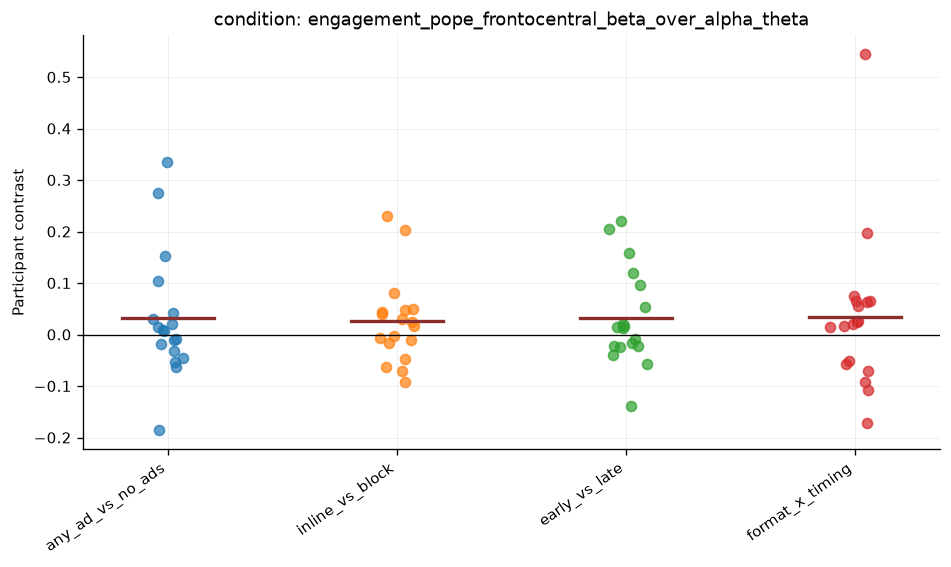

,count,mean,std,min,25%,50%,75%,max
contrast_id,,,,,,,,
any_ad_vs_no_ads,18.0,0.0319,0.1219,-0.1862,-0.0279,0.0080,0.0383,0.3359
early_vs_late,18.0,0.0326,0.0940,-0.1388,-0.0225,0.0135,0.0855,0.2209
format_x_timing,18.0,0.0345,0.1528,-0.1711,-0.0551,0.0223,0.0648,0.5445
inline_vs_block,18.0,0.0254,0.0837,-0.0912,-0.0148,0.0208,0.0461,0.2311


In [12]:
# Edit these values and rerun the cell.
ANALYSIS_TO_EXPLORE = "condition"  # "condition" or "ad"
FEATURE_TO_EXPLORE = "engagement_pope_frontocentral_beta_over_alpha_theta"

score_source = condition_scores if ANALYSIS_TO_EXPLORE == "condition" else ad_scores
selected = score_source[score_source["feature"].eq(FEATURE_TO_EXPLORE)].copy()
if selected.empty:
    available = sorted(score_source["feature"].unique())
    raise ValueError(f"Unknown feature. Choose one of: {available}")

contrast_order = list(selected["contrast_id"].drop_duplicates())
fig, ax = plt.subplots(figsize=(max(8, len(contrast_order) * 1.25), 4.8))
rng = np.random.default_rng(20260803)
for index, contrast_id in enumerate(contrast_order):
    values = selected.loc[selected["contrast_id"].eq(contrast_id), "difference"].to_numpy()
    ax.scatter(np.full(len(values), index) + rng.normal(0, 0.045, len(values)), values, alpha=0.7)
    ax.plot([index - 0.2, index + 0.2], [values.mean(), values.mean()], color="#8A2D2D", linewidth=2)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(range(len(contrast_order)), contrast_order, rotation=35, ha="right")
ax.set_ylabel("Participant contrast")
ax.set_title(f"{ANALYSIS_TO_EXPLORE}: {FEATURE_TO_EXPLORE}")
plt.tight_layout()
plt.show()

display(selected.groupby("contrast_id")["difference"].describe().round(4))

## 10. Initial interpretation

The generated narrative is intentionally conservative. It reports compatible effect ranges and robustness without converting non-significance into evidence that advertisements have no EEG effect.

In [13]:
display(Markdown((OUTPUT_ROOT / "reports/initial_results_summary.md").read_text()))

# Initial publication analysis summary

## Scope

This report summarizes the frozen `frozen_v3` EEG datasets for 18 laboratory
participants. It is an initial analysis scaffold, not a final claim of
neurophysiological or causal evidence.

## Confirmatory results

No primary sustained-condition or ad-response contrast survives its
feature-specific Holm family at α=0.05.

The smallest corrected sustained-condition result is
`early_vs_late` for `posterior_alpha_power_db_uv2`
(`mean=-0.089`,
`95% CI [-0.201, 0.023]`,
`dz=-0.395`,
`p_Holm=0.337`,
`p_global_Holm=0.674`).

The smallest corrected ad-response result is
`inline_late_vs_no_ad_late` for `fz_theta_power_db_uv2`
(`mean=-1.992`,
`95% CI [-3.942, -0.042]`,
`dz=-0.508`,
`p_Holm=0.183`,
`p_global_Holm=0.366`).

## Robustness

The 1,000 and 1,500 µV sensitivity branches preserve all confirmatory effect
directions and corrected conclusions relative to the 1,050 µV primary policy.
The minimum leave-one-participant-out sign stability across primary-feature
diagnostics is 55.6%.

## Interpretation boundaries

- The sample is small (`n=18`), so confidence intervals and participant-level
  distributions should lead interpretation.
- Laboratory feedback identifies `Cz` as the online reference and `Fpz` as
  ground; the XDF does not encode those physical roles directly.
- Current feature tables are no-ICA. An ICA branch retaining 99% PCA variance
  and using `Fp1/Fp2` as ocular proxies must be visually validated before the
  final primary policy is chosen.
- Baseline eye state was uncontrolled and is excluded from confirmatory tests.
- Engagement ratios, FAA, global bands, and uncorrected interactions are
  secondary or exploratory.
- The era-aware read-versus-write positive control is not yet implemented;
  null condition results therefore do not establish universal pipeline
  sensitivity.
- A non-significant result is not evidence of absence; report compatible effect
  ranges and study power limitations.

## Automated quality review

20 of 20 analysis gates pass.


## 11. Planned behavioral–EEG integration

Do not join behavioral outcomes ad hoc. First freeze a behavioral contract containing:

- one stable participant identifier mapped to `subject_id`;
- condition and ad-reference identifiers at compatible grain;
- prespecified outcomes such as trust, convincingness, helpfulness, relevance, manipulation, recall, and response latency;
- missingness and exclusion fields;
- explicit direction coding for every scale.

Then create a separate multimodal table at participant × condition or participant × ad-response grain. Candidate models should use participant random intercepts or participant-level contrasts, control multiplicity, and keep engagement indices exploratory.

## Remaining publication gates

1. Approve filtering and interpolation figures.
2. Implement and visually validate the 99%-variance ICA branch using Fp1/Fp2 as ocular proxies.
3. Compare ICA with the current no-ICA sensitivity and select the final primary branch.
4. Keep all three engagement metrics and decide their final inferential tier.
5. Optionally verify the reported Cz reference/Fpz ground handling from the acquisition workspace.
6. Implement the era-aware read-versus-write positive control before interpreting null condition effects as evidence of pipeline sensitivity.
7. Freeze behavioral schemas before multimodal integration.
8. Convert these initial figures and tables into manuscript-specific numbering and captions only after scientific review.

In [14]:
# Reproducibility record: every source path and SHA-256 hash used by the runner.
manifest_view = json.loads((OUTPUT_ROOT / "reports/analysis_manifest.json").read_text())
inputs = pd.DataFrame([
    {"input": name, **details} for name, details in manifest_view["inputs"].items()
])
display(inputs)
print("Human gates:")
for gate in manifest_view["human_gates"]:
    print(f"- {gate}")

,input,path,sha256
0,condition_features,src/project/logs/xdf/gold/features/condition_f...,2f967e35ecf48df95b5eb4146cf1c172dcbdba4e4a1a0e...
1,condition_epochs,src/project/logs/xdf/gold/features/condition_e...,6b73763fe21afae298e46dc87628c0cdda19e9d7e1d6e7...
2,ad_responses,src/project/logs/xdf/gold/features/ad_response...,438e91940df32ab1d1298c447034149a932bef4296f4d3...
3,condition_validation,src/project/logs/xdf/gold/features/condition_f...,a07699bcbb16da83c1db3839cf01ebe69d3c37e5091fb8...
4,ad_validation,src/project/logs/xdf/gold/features/ad_feature_...,ac2abab4f482e3668144c514bbdfa8c17a5bef614b3f0d...
5,engagement_validation,src/project/logs/xdf/gold/features/engagement_...,d6eb72d66c473c83f04d2445f466c9535e4911d575ce1f...
6,soundness_validation,src/project/logs/xdf/gold/validation/preproces...,8450e176af84a7c9d0e02eb94d12331d4bc01782d7d23a...
7,condition_tests,analysis/eeg/statistics/outputs/eeg_condition_...,f09529420194b8c8df9b001d26b4d6320d79c17448dd10...
8,condition_scores,analysis/eeg/statistics/outputs/eeg_condition_...,7efe386770799dcb6fff9a1ac940412dbd6177fd2fa02e...
9,ad_tests,analysis/eeg/statistics/outputs/eeg_ad_respons...,edec086379faa42d5385145baa61c8fbc0fa01a03a80f1...


Human gates:
- Approve filtering and interpolation figures.
- If available, verify Cz/Fpz handling against the acquisition workspace because Cz is also exported as a dynamic data channel.
- Implement and validate the 99%-variance ICA branch, then compare it with the required no-ICA sensitivity.
- Confirm engagement indices remain exploratory.
- Implement and interpret the read-versus-write positive control before treating null condition effects as evidence of pipeline sensitivity.
- Integrate behavioral covariates only after their data contract is frozen.
